In [18]:
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
# 2. Carregamento e fusão de dados
# 2.1. Carregar dataframe de preditores ERA5/ERA5-Land
era5_df = pd.read_csv(
    "/home/lacrio2/Documentos/LACRIO/PROJETO/LACRIO/Pre-processamento/dados_csv/dados_era5_era5land.csv", parse_dates=["date"]
)  # contém colunas ['date', 'z_300', ..., 'sf']

# 2.2. Carregar dados da estação local (CSV)
station_df = pd.read_csv(
    "/home/lacrio2/Documentos/LACRIO/PROJETO/LACRIO/Pre-processamento/dados_csv/dados_estacao_cuchillacocha.csv", parse_dates=["data"]
)  # colunas ['date', 'temp_obs', 'prec_obs']

station_df = station_df.rename(
    columns={
        "data": "date",  # Renomear a coluna de data para 'date' para compatibilidade
        "Temperatura": "temp_obs",
        "Precipitação": "prec_obs"  # Substitua pelo nome real da coluna de temperatura
    })


# 2.3. Mesclar dados pelo índice temporal
# Inner join garante datas comuns
data = pd.merge(era5_df, station_df, on="date", how="inner")

# 3. Incorporação do DEM e cálculo de alt_diff
# Carregar DEM NetCDF
dem = xr.open_dataset(
    "/home/lacrio2/Documentos/LACRIO/PROJETO/LACRIO/Dados_DEM/Quilcayhuanca_static.nc"
)
# Coordenadas da estação
lat_sta, lon_sta = -27.085, -48.905  # ajuste conforme sua estação
# Extrair altitude local
elev_local = float(
    dem['HGT'].sel(lat=lat_sta, lon=lon_sta, method='nearest')
)
# Converter geopotencial do ERA5 (coluna 'z') para altitude em metros
# geopotencial [m2/s2] dividido por gravidade [m/s2]
data['alt_ERA5'] = data['z'] / 9.80665
# Diferença de altitude
data['alt_diff'] = elev_local - data['alt_ERA5']

# 3.5. Remover quaisquer linhas com NaNs (features ou alvos)
# Garante que não haja valores faltantes antes de definir X/y e divisão de treino/teste
data = data.dropna().reset_index(drop=True)

# 4. Agregação diária (se ERA5 for horário)
# era5_daily = era5_df.set_index('date').resample('D').agg(...)
# data = pd.merge(era5_daily, station_df, on='date', how='inner')

# 5. Definição de features (X) e alvos (y)
features = [
    c for c in data.columns
    if c not in ['date', 'temp_obs', 'prec_obs']
]
X = data[features]
y_temp = data['temp_obs']
y_prec = data['prec_obs']

# 6. Divisão treino/teste considerando série temporal
split_date = pd.to_datetime('2018-01-01')
train_mask = data['date'] < split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_temp_train, y_temp_test = y_temp[train_mask], y_temp[~train_mask]
y_prec_train, y_prec_test = y_prec[train_mask], y_prec[~train_mask]


In [20]:
models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr',      LinearRegression())
    ]),
    'DecisionTree': Pipeline([
        ('scaler', StandardScaler()),
        ('dt', DecisionTreeRegressor(
            max_depth=None,
            min_samples_leaf=1,
            random_state=42
        ))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(
            n_estimators=100,
            min_samples_leaf=5,
            max_depth=None,
            random_state=42
        ))
    ]),
    'ExtraTrees': Pipeline([
        ('scaler', StandardScaler()),
        ('et', ExtraTreesRegressor(
            n_estimators=100,
            min_samples_leaf=5,
            max_depth=None,
            random_state=42
        ))
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(
            use_label_encoder=False,
            eval_metric='rmse',
            random_state=42
        ))
    ]),
}


In [21]:
# 8. Validação inicial com TimeSeriesSplit
# Converter para arrays NumPy para slicing
X_train_arr = X_train.values
y_temp_arr = y_temp_train.values

In [22]:
# Definir divisão temporal com 5 folds
from sklearn.model_selection import TimeSeriesSplit


ts = TimeSeriesSplit(n_splits=5)
results_temp = {}
for name, pipeline in models.items():
    rmses = []
    for train_idx, val_idx in ts.split(X_train_arr):
        X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        y_tr, y_val = y_temp_arr[train_idx], y_temp_arr[val_idx]
        # Garante não haver NaNs no subset de treino
        mask_notnan = ~np.isnan(y_tr)
        X_tr_f, y_tr_f = X_tr[mask_notnan], y_tr[mask_notnan]
        pipeline.fit(X_tr_f, y_tr_f)
        y_pred = pipeline.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
    results_temp[name] = np.mean(rmses)
print("RMSE médio (validação) - Temperatura:", results_temp)

/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:19:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:19:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:19:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:19:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RMSE médio (validação) - Temperatura: {'LinearRegression': np.float64(0.8394493963028404), 'DecisionTree': np.float64(1.2758174958076092), 'RandomForest': np.float64(0.8690727979861002), 'ExtraTrees': np.float64(0.8732390611155585), 'SVR': np.float64(0.9194606930922372), 'XGBoost': np.float64(0.9528130859015519)}


/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:19:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [23]:
# 9. GridSearchCV para RandomForest (Temperatura)
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV


grid_rf = GridSearchCV(
    models['RandomForest'],
    param_grid={
        'rf__n_estimators': [100, 200],
        'rf__max_depth': [None, 10, 20],
        'rf__min_samples_leaf': [1, 5]
    },
    cv=ts,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_rf.fit(X_train, y_temp_train)
print("Melhores parâmetros RF:", grid_rf.best_params_)
print("Melhor RMSE (CV):", np.sqrt(-grid_rf.best_score_))

# 10. Avaliação no conjunto de teste (Temperatura)
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train, y_temp_train)
y_temp_pred = best_rf.predict(X_test)
print(
    "Teste Temperatura ->",
    "RMSE=", np.sqrt(mean_squared_error(y_temp_test, y_temp_pred)),
    "MAE=", mean_absolute_error(y_temp_test, y_temp_pred),
    "R2=", r2_score(y_temp_test, y_temp_pred)
)

Melhores parâmetros RF: {'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}
Melhor RMSE (CV): 0.8947289800935174
Teste Temperatura -> RMSE= 0.732944542605365 MAE= 0.581952535812454 R2= 0.5416175792555179


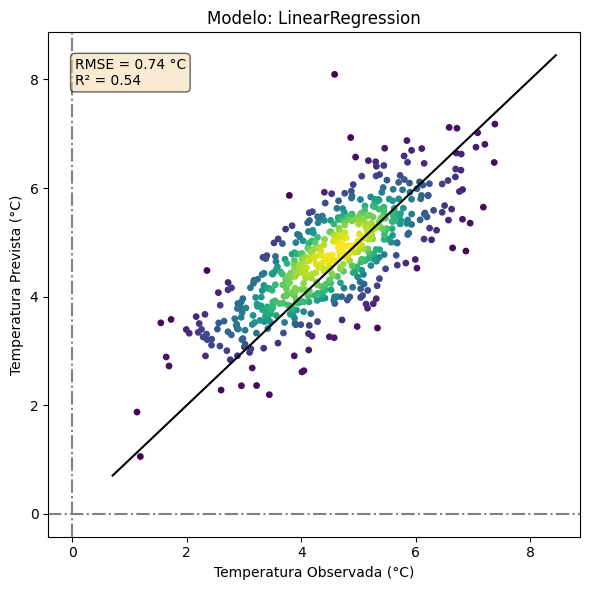

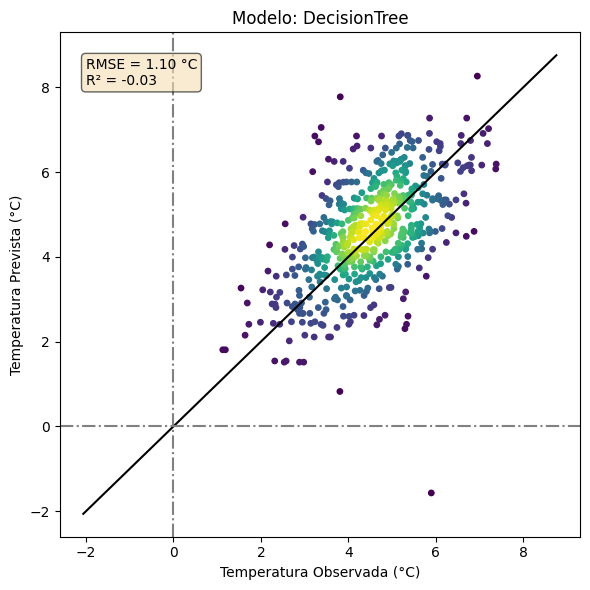

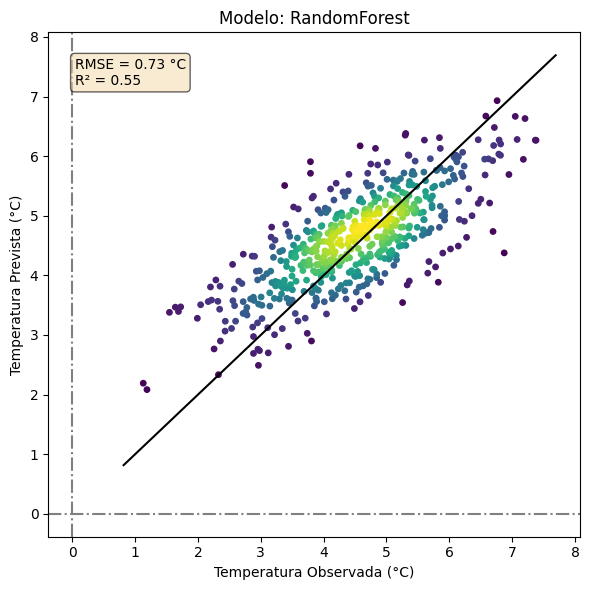

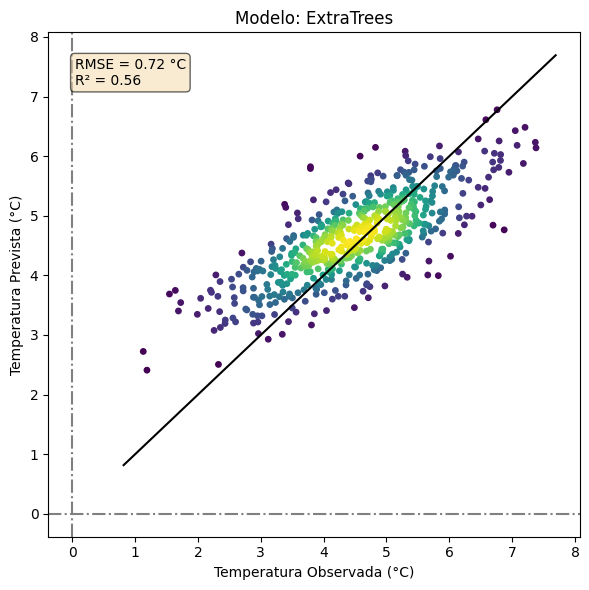

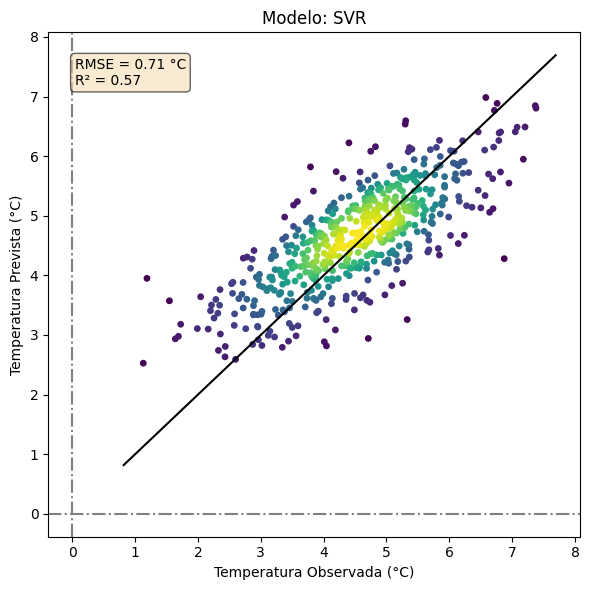

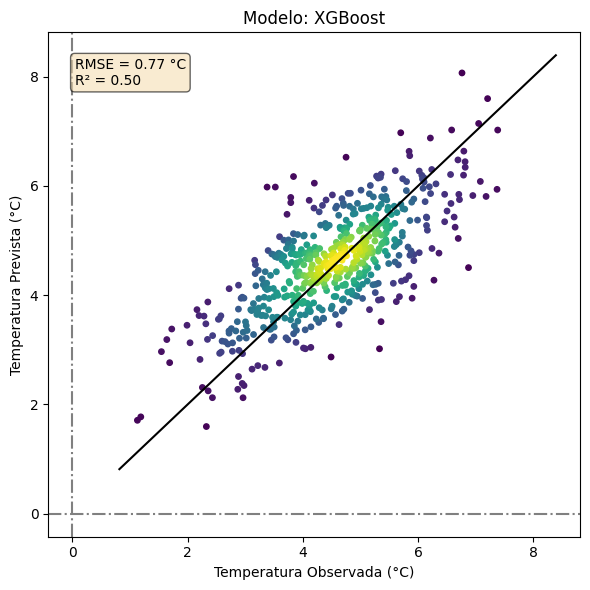

In [24]:

# === 3) Função para plotar scatter colorido por densidade ===
def plot_density_scatter(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # Calcula densidade com KDE
    xy = np.vstack([y_true, y_pred])
    z  = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = y_true[idx], y_pred[idx], z[idx]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x, y, c=z, s=15)
    # Linha 1:1
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, '-', color='black')
    # Linhas x=0 e y=0
    ax.axhline(0, linestyle='dashdot', color='gray')
    ax.axvline(0, linestyle='dashdot', color='gray')

    ax.set_title(f"Modelo: {model_name}")
    ax.set_xlabel("Temperatura Observada (°C)")
    ax.set_ylabel("Temperatura Prevista (°C)")

    ax.text(
        0.05, 0.95,
        f"RMSE = {rmse:.2f} °C\nR² = {r2:.2f}",
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='wheat', alpha=0.6)
    )
    plt.tight_layout()
    plt.show()

# === 4) Avaliação gráfica em X_temp_test / y_temp_test ===
# Atenção: deve existir em memória X_temp_test e y_temp_test
X_test_arr   = X_test.to_numpy()
y_test_arr   = y_temp_test.to_numpy()

for name, pipe in models.items():
    y_pred = pipe.predict(X_test_arr)
    plot_density_scatter(y_test_arr, y_pred, name)


In [25]:
# Validação inicial com TimeSeriesSplit
# Converter para arrays NumPy para slicing
X_train_arr = X_train.values
y_temp_arr = y_prec_train.values

In [27]:
# Definir divisão temporal com 5 folds
from sklearn.model_selection import TimeSeriesSplit


ts = TimeSeriesSplit(n_splits=5)
results_temp = {}
for name, pipeline in models.items():
    rmses = []
    for train_idx, val_idx in ts.split(X_train_arr):
        X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
        y_tr, y_val = y_temp_arr[train_idx], y_temp_arr[val_idx]
        # Garante não haver NaNs no subset de treino
        mask_notnan = ~np.isnan(y_tr)
        X_tr_f, y_tr_f = X_tr[mask_notnan], y_tr[mask_notnan]
        pipeline.fit(X_tr_f, y_tr_f)
        y_pred = pipeline.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
    results_temp[name] = np.mean(rmses)
print("RMSE médio (validação) - precipitação:", results_temp)

/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:21:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:21:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:21:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:21:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RMSE médio (validação) - precipitação: {'LinearRegression': np.float64(6.360083838047352), 'DecisionTree': np.float64(6.133428778991311), 'RandomForest': np.float64(3.898629684051623), 'ExtraTrees': np.float64(3.8464729929397654), 'SVR': np.float64(4.271352749162537), 'XGBoost': np.float64(4.412471853566194)}


/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:21:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [29]:
# 11. GridSearchCV para XGBoost (Precipitação)
grid_prec = GridSearchCV(
    models['XGBoost'],
    param_grid={
        'xgb__n_estimators': [100, 200],
        'xgb__max_depth': [3, 6]
    },
    cv=ts,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_prec.fit(X_train, y_prec_train)
print("Melhores parâmetros XGBoost:", grid_prec.best_params_)
print("Melhor RMSE (CV):", np.sqrt(-grid_prec.best_score_))

# 12. Avaliação no conjunto de teste (Precipitação)
best_xgb = grid_prec.best_estimator_
y_prec_pred = best_xgb.predict(X_test)
print(
    "Teste Precipitação ->",
    "RMSE=", np.sqrt(mean_squared_error(y_prec_test, y_prec_pred)),
    "MAE=", mean_absolute_error(y_prec_test, y_prec_pred),
    "R2=", r2_score(y_prec_test, y_prec_pred)
)


/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:25:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:25:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:25:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:25:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/lacrio2/miniconda3/lib/python3.12/site

Melhores parâmetros XGBoost: {'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Melhor RMSE (CV): 4.284327654566668
Teste Precipitação -> RMSE= 4.0540686899998315 MAE= 2.44483646869432 R2= 0.39106060336909476


/home/lacrio2/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:25:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


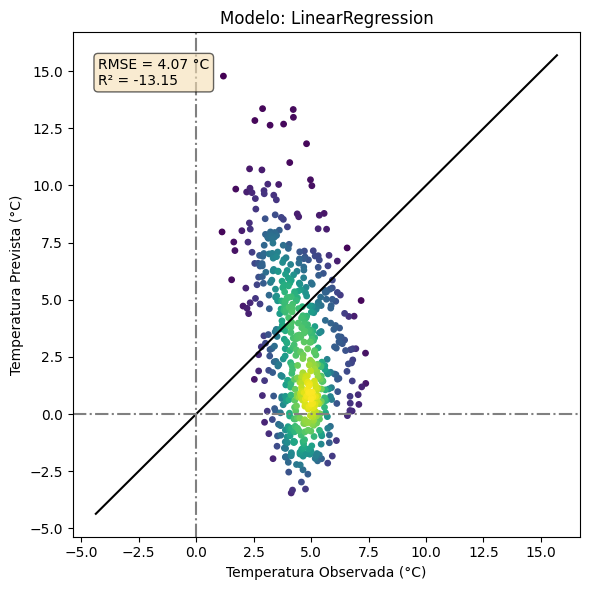

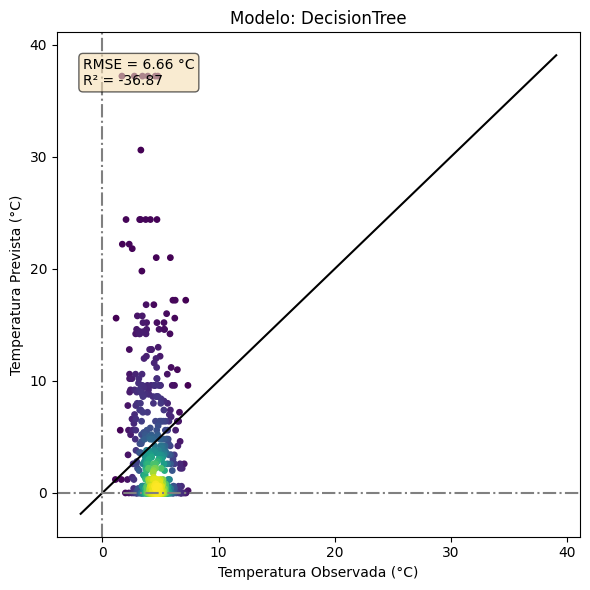

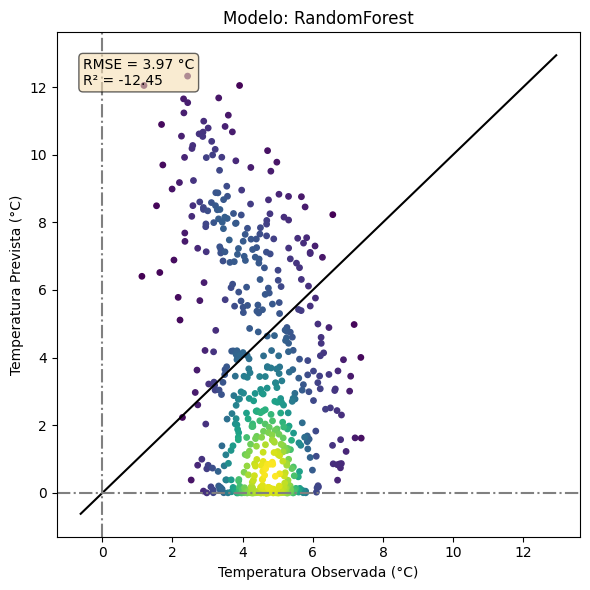

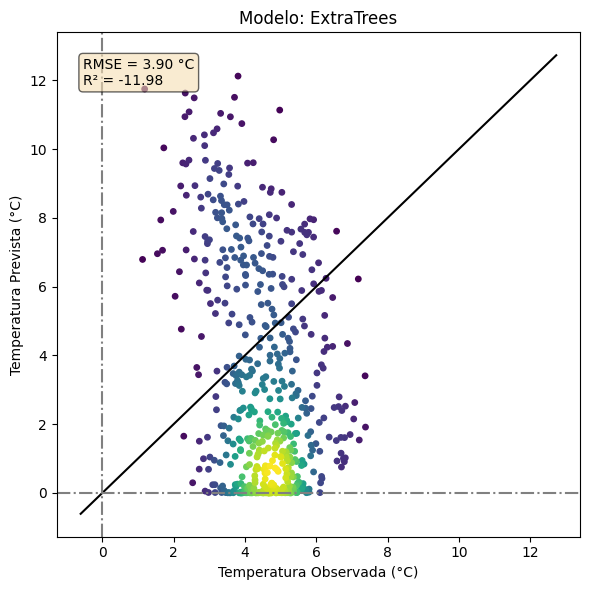

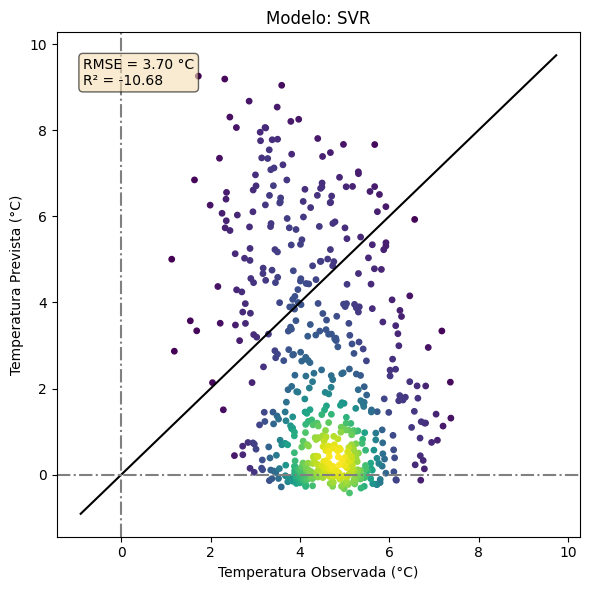

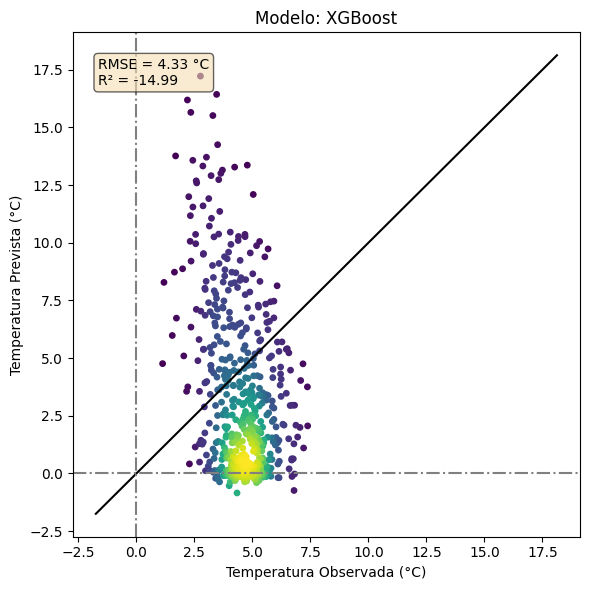

In [30]:
for name, pipe in models.items():
    y_pred = pipe.predict(X_test_arr)
    plot_density_scatter(y_test_arr, y_pred, name)


In [ ]:
# 13. Geração de série histórica downscaled
era_all = pd.read_csv(
    "/caminho/para/era5_features_completo.csv",
    parse_dates=['date']
)
era_all['alt_ERA5'] = era_all['z'] / 9.80665
era_all['alt_diff'] = elev_local - era_all['alt_ERA5']

# Remover NaNs antes de aplicar modelos
era_all = era_all.dropna().reset_index(drop=True)
X_all = era_all[features].values
era_all['temp_downscaled'] = best_rf.predict(X_all)
era_all['prec_downscaled'] = best_xgb.predict(X_all)
era_all[['date', 'temp_downscaled', 'prec_downscaled']].to_csv(
    "downscaled_series.csv", index=False
)